# Customer Churn Prediction System

TEYZIX CORE Internship ML Task 2. This notebook documents the end-to-end workflow:
dataset inspection, data preparation, feature engineering, model training, evaluation,
and prediction usage.

In [1]:
from pathlib import Path
import json
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "customer_churn_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Customer_ID,Age,Gender,City,Subscription_Type,Monthly_Spending,Tenure_Months,Number_of_Purchases,Support_Requests,Login_Frequency,...,Satisfaction_Score,Payment_Method,Contract_Type,Discount_Used,Referral_Source,Auto_Renew,Device_Type,Internet_Speed,Customer_Lifetime_Value,Churn
0,CUST000034,30.0,Male,Indianapolis,Basic,16.21,21.0,23.0,3.0,70.0,...,6.0,Cash,Quarterly,No,Friend,Yes,Desktop,Slow,355.60,No
1,CUST001234,41.0,Male,Nashville,Premium,108.84,8.0,3.0,6.0,0.0,...,4.0,Credit Card,Quarterly,No,Email Campaign,No,Desktop,Fast,1130.76,Yes
2,CUST000367,31.0,Female,Portland,Premium,79.73,16.0,13.0,1.0,48.0,...,8.0,Debit Card,Monthly,No,Friend,No,Android,Slow,1437.04,No
3,CUST000803,44.0,Male,Charlotte,Basic,13.62,16.0,4.0,4.0,27.0,...,6.0,Debit Card,Quarterly,No,Organic Search,Yes,Android,Slow,155.79,Yes
4,CUST000513,41.0,Male,Philadelphia,Basic,18.35,9.0,6.0,2.0,15.0,...,6.0,Debit Card,Quarterly,No,Organic Search,No,iPhone,Fast,389.20,Yes


## Dataset Overview

In [2]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.dtypes)
display(df.isna().sum())
print("Duplicates:", df.duplicated().sum())
display(df["Churn"].value_counts(normalize=True).rename("share"))

Rows: 2,015
Columns: 21


Customer_ID                    str
Age                        float64
Gender                         str
City                           str
Subscription_Type              str
Monthly_Spending           float64
Tenure_Months              float64
Number_of_Purchases        float64
Support_Requests           float64
Login_Frequency            float64
Last_Activity_Days_Ago     float64
Satisfaction_Score         float64
Payment_Method                 str
Contract_Type                  str
Discount_Used                  str
Referral_Source                str
Auto_Renew                     str
Device_Type                    str
Internet_Speed                 str
Customer_Lifetime_Value    float64
Churn                          str
dtype: object

Customer_ID                 0
Age                        40
Gender                     40
City                       40
Subscription_Type          40
Monthly_Spending           41
Tenure_Months              40
Number_of_Purchases        41
Support_Requests           40
Login_Frequency            40
Last_Activity_Days_Ago     40
Satisfaction_Score         40
Payment_Method             40
Contract_Type              40
Discount_Used              40
Referral_Source            41
Auto_Renew                 40
Device_Type                40
Internet_Speed             40
Customer_Lifetime_Value    40
Churn                       0
dtype: int64

Duplicates: 15


Churn
No     0.699752
Yes    0.300248
Name: share, dtype: float64

## Train Models and Generate Artifacts

In [3]:
# Run the reproducible training pipeline.
# It creates model files, metrics, report markdown, cleaned data, and plots.
import sys
sys.path.insert(0, str(ROOT / "src"))

import train_model
train_model.main()

Best model: Gradient Boosting
{
  "accuracy": 0.8925,
  "precision": 0.8181818181818182,
  "recall": 0.825,
  "f1_score": 0.8215767634854771,
  "roc_auc": 0.9668154761904761,
  "confusion_matrix": [
    [
      258,
      22
    ],
    [
      21,
      99
    ]
  ],
  "classification_report": {
    "Not Churn": {
      "precision": 0.9247311827956989,
      "recall": 0.9214285714285714,
      "f1-score": 0.9230769230769231,
      "support": 280.0
    },
    "Churn": {
      "precision": 0.8181818181818182,
      "recall": 0.825,
      "f1-score": 0.8215767634854771,
      "support": 120.0
    },
    "accuracy": 0.8925,
    "macro avg": {
      "precision": 0.8714565004887586,
      "recall": 0.8732142857142857,
      "f1-score": 0.8723268432812001,
      "support": 400.0
    },
    "weighted avg": {
      "precision": 0.8927663734115348,
      "recall": 0.8925,
      "f1-score": 0.8926268751994892,
      "support": 400.0
    }
  }
}


## Evaluation Metrics

In [4]:
metadata = json.loads((ROOT / "models" / "model_metadata.json").read_text())
print("Best model:", metadata["best_model"])
pd.DataFrame(metadata["model_comparison"]).T[
    ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
].sort_values("roc_auc", ascending=False)

Best model: Gradient Boosting


,accuracy,precision,recall,f1_score,roc_auc
Gradient Boosting,0.8925,0.818182,0.825,0.821577,0.966815
Logistic Regression,0.9025,0.804511,0.891667,0.84585,0.964345
Tuned Random Forest,0.8875,0.781955,0.866667,0.822134,0.963542
Random Forest,0.895,0.8,0.866667,0.832,0.96244


## Feature Importance

In [5]:
importance = pd.read_csv(ROOT / "reports" / "feature_importance.csv")
importance.head(15)

,feature,importance
0,Engagement_Score,0.549338
1,Login_Frequency,0.108717
2,Contract_Type_Monthly,0.081450
3,Last_Activity_Days_Ago,0.065824
4,Contract_Type_Yearly,0.027564
5,Purchases_Per_Tenure,0.026101
6,Auto_Renew_No,0.024212
7,Satisfaction_Score,0.023161
8,Auto_Renew_Yes,0.015138
9,Support_Requests_Per_Tenure,0.013379


## Generated Visuals

churn_distribution.png


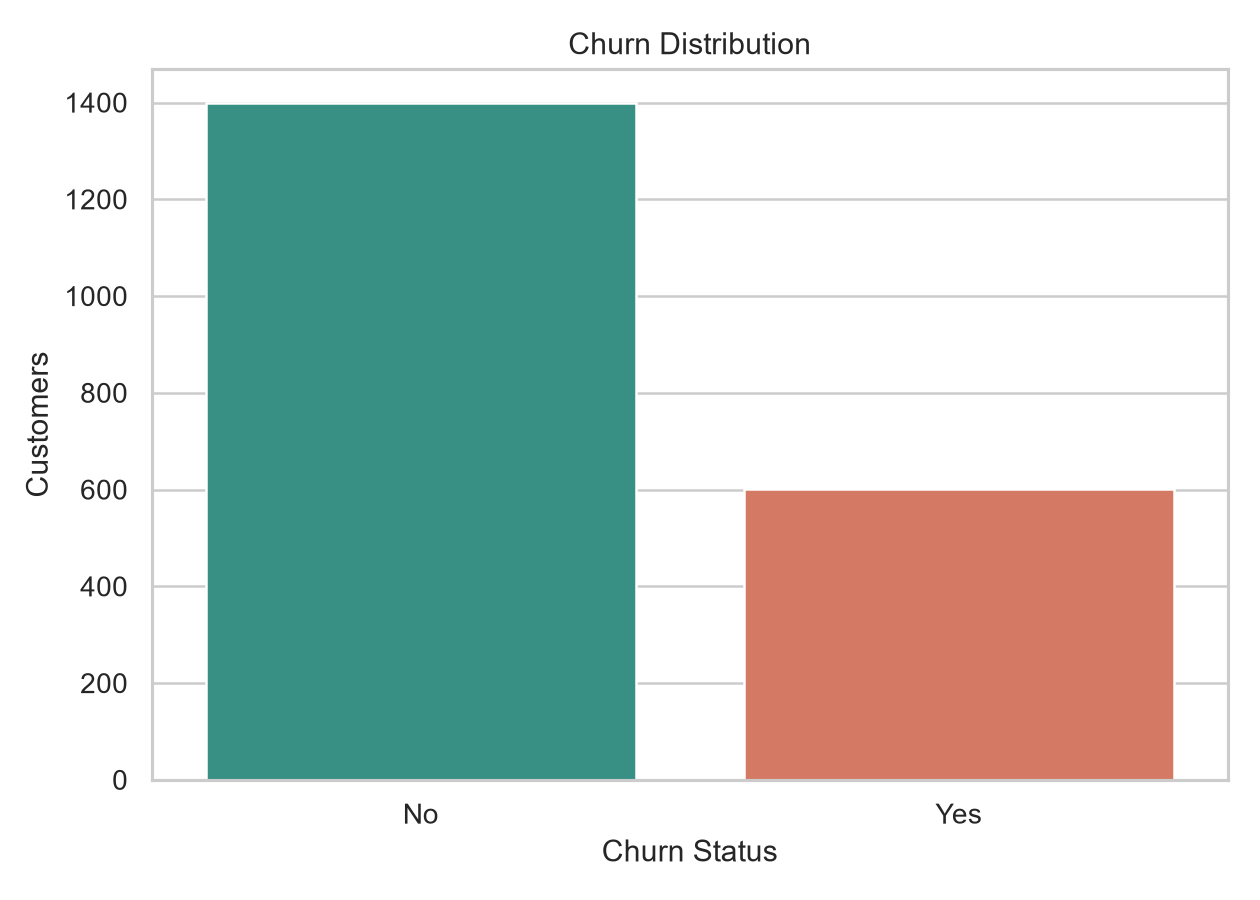

monthly_spending_by_churn.png


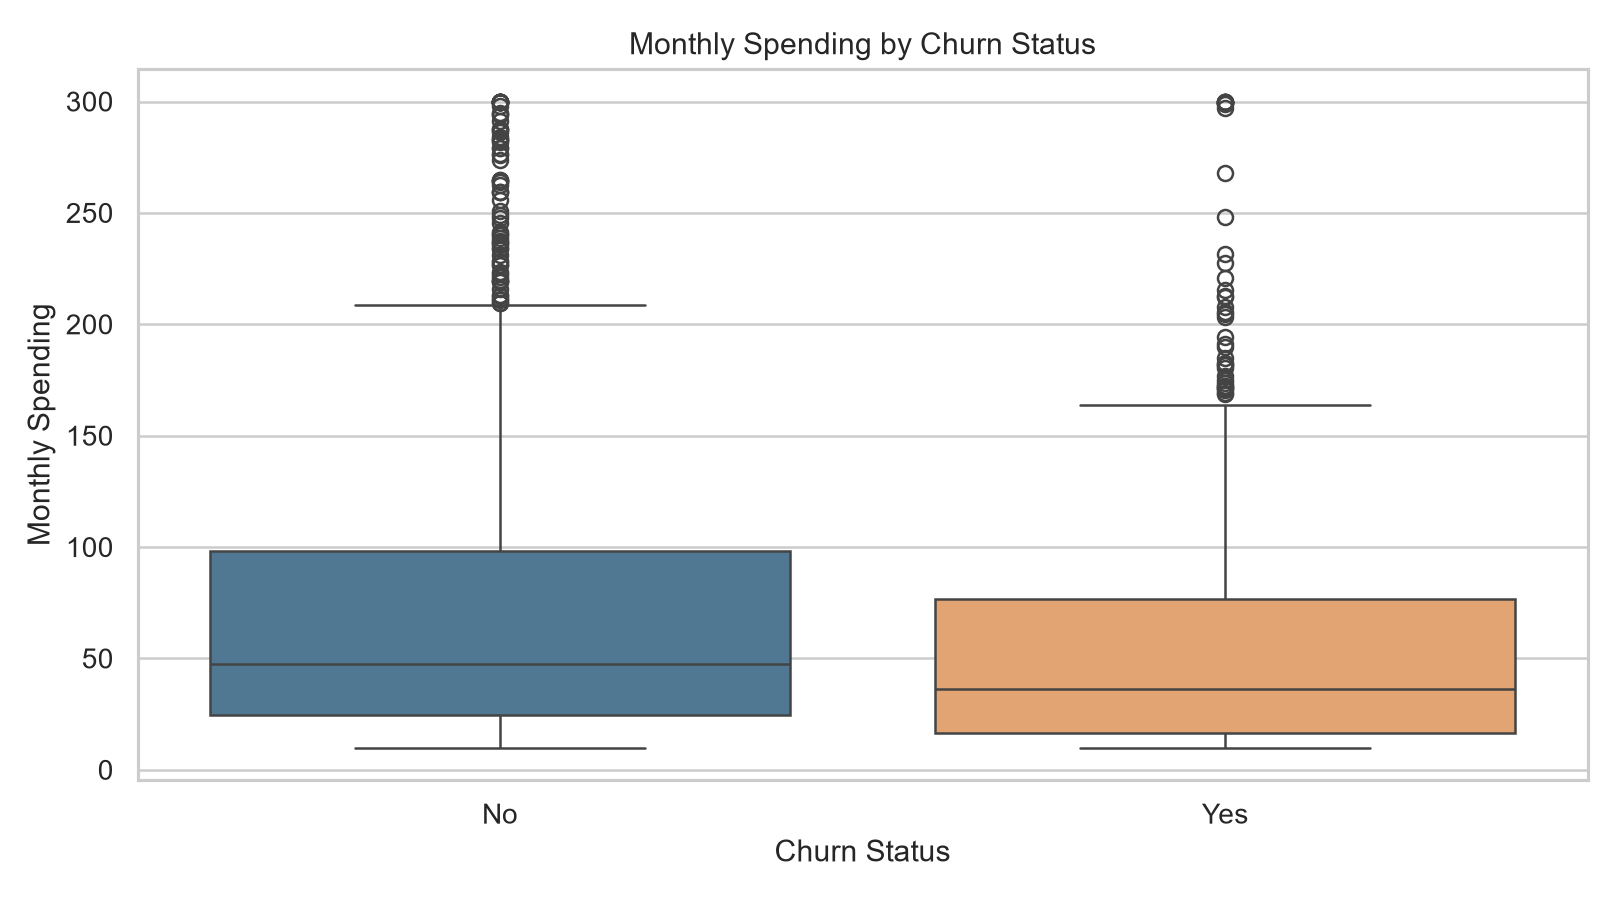

satisfaction_by_churn.png


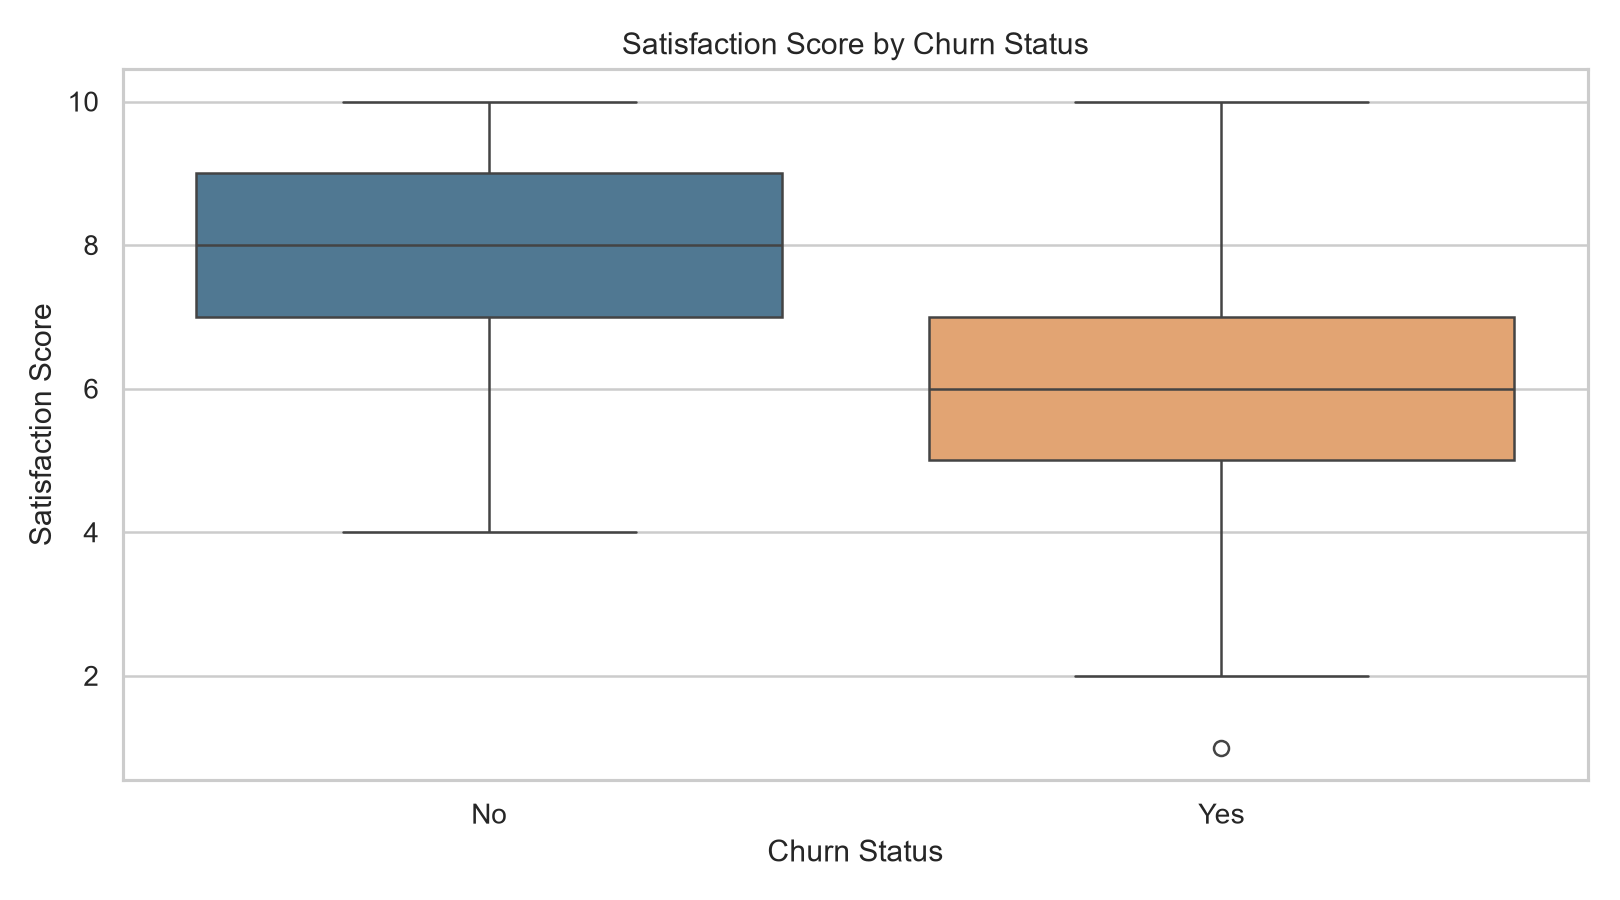

confusion_matrix.png


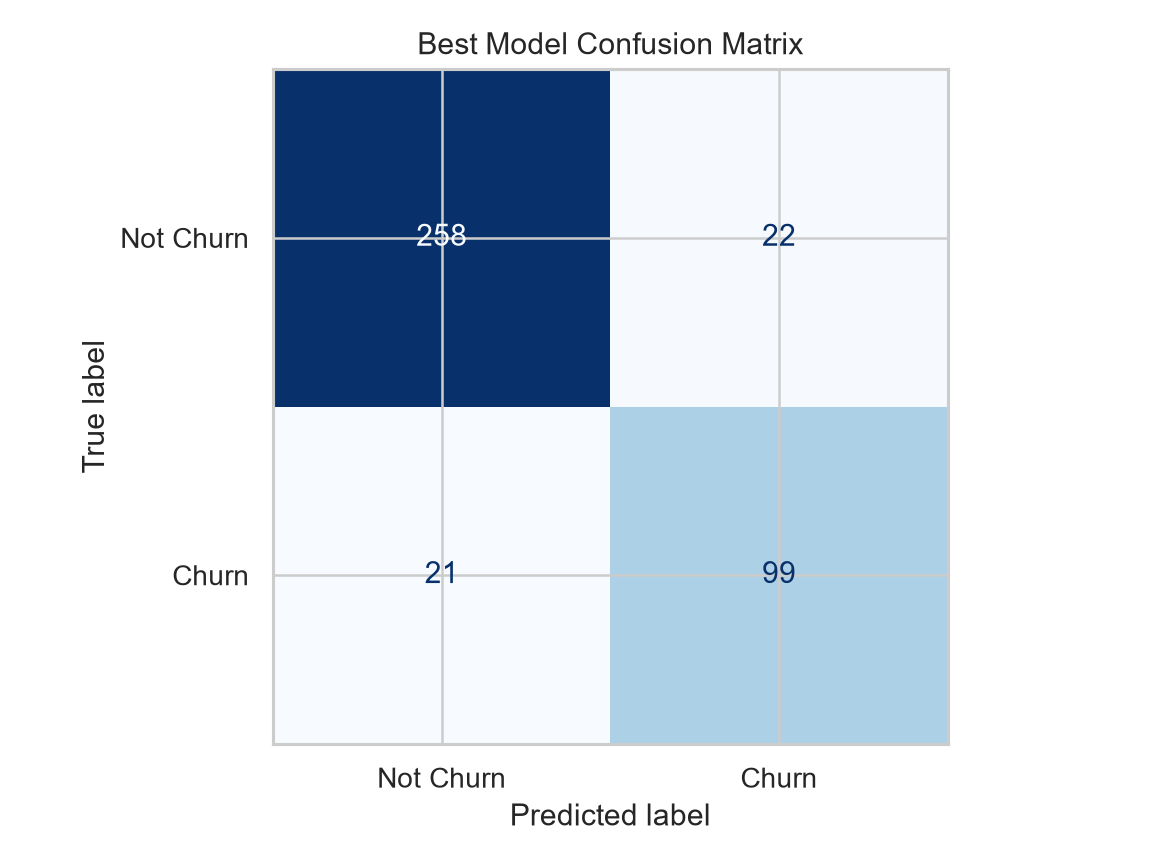

roc_curve.png


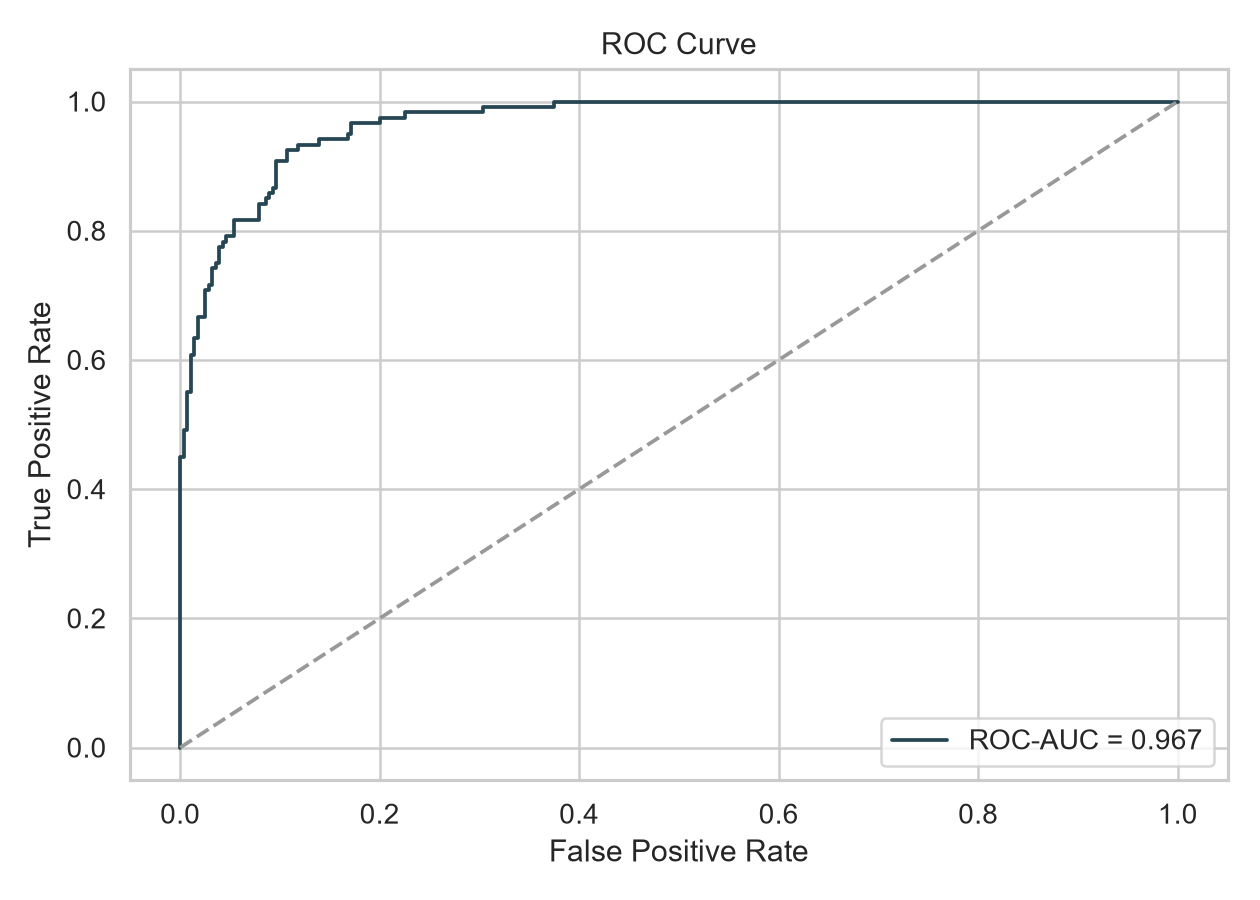

feature_importance.png


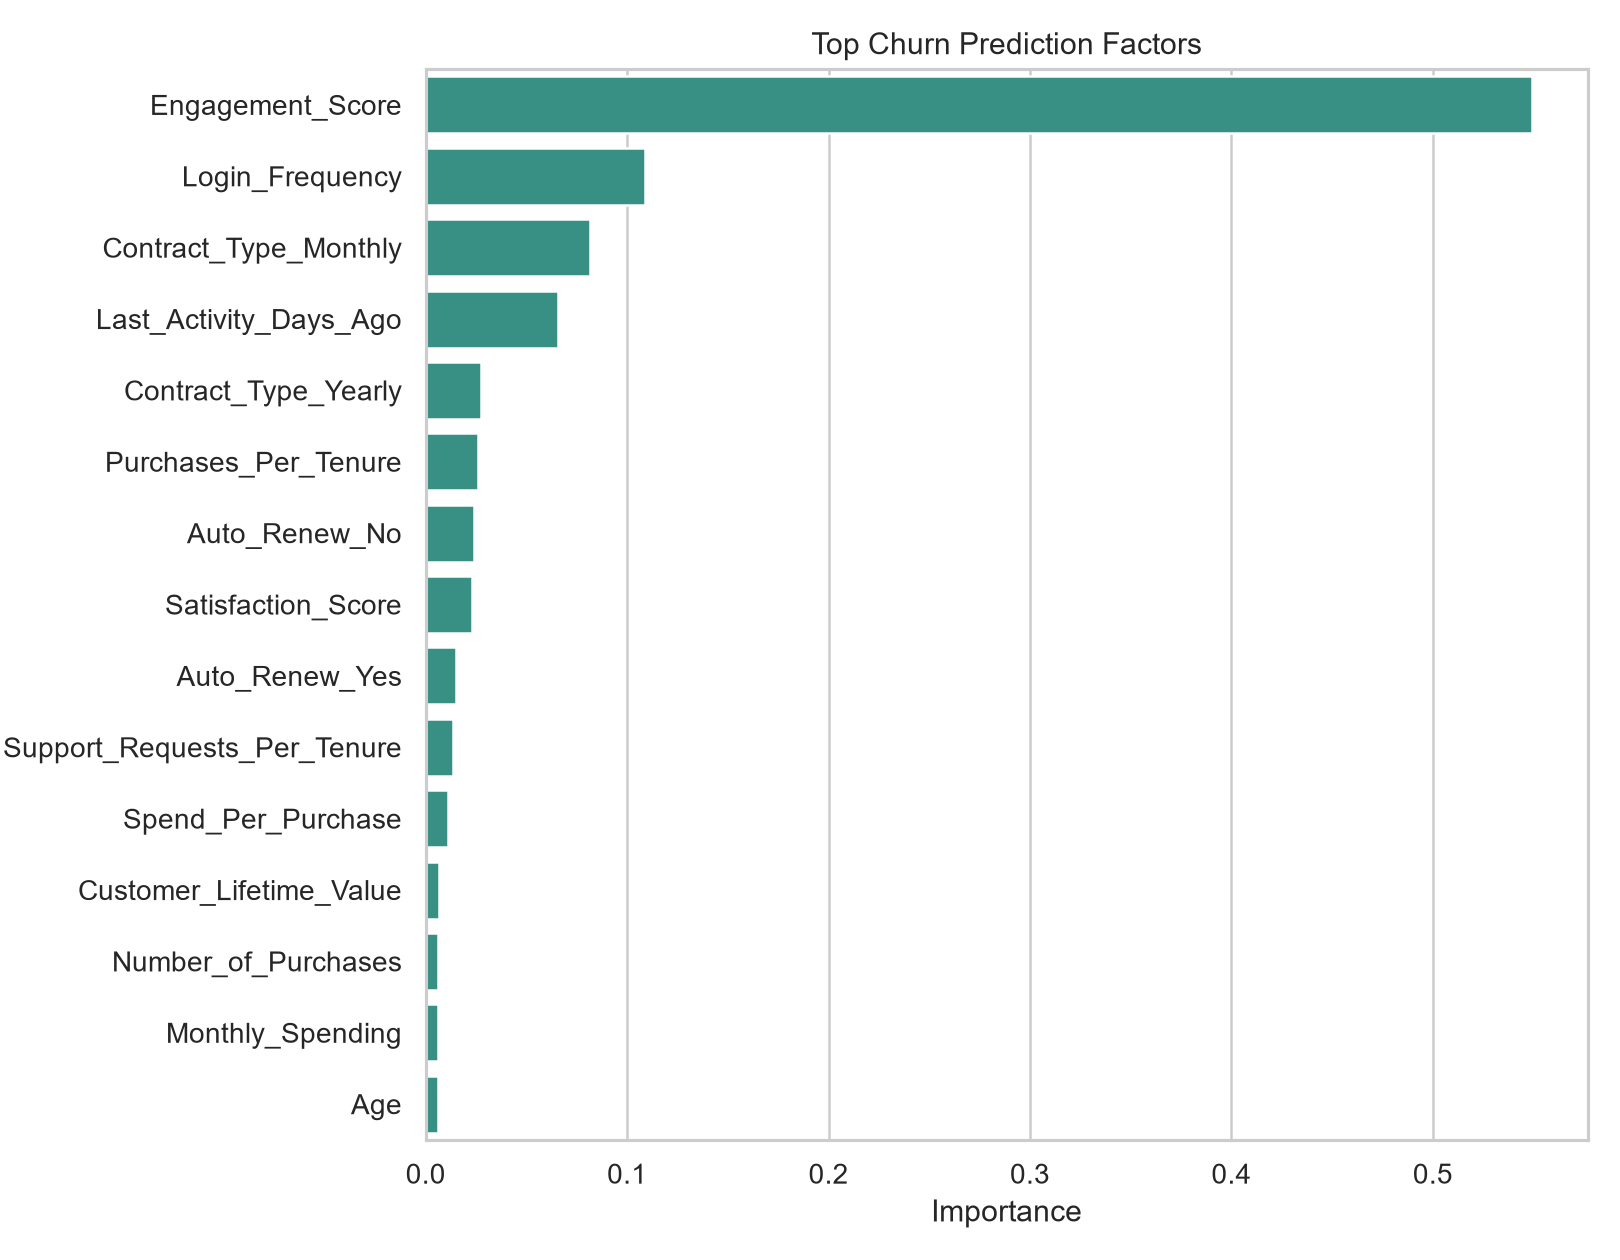

In [6]:
from IPython.display import Image, display

for name in [
    "churn_distribution.png",
    "monthly_spending_by_churn.png",
    "satisfaction_by_churn.png",
    "confusion_matrix.png",
    "roc_curve.png",
    "feature_importance.png",
]:
    print(name)
    display(Image(filename=str(ROOT / "reports" / "figures" / name)))

## Prediction Interface Example

In [7]:
sample_customer = {
    "Age": 41,
    "Gender": "Male",
    "City": "Nashville",
    "Subscription_Type": "Premium",
    "Monthly_Spending": 108.84,
    "Tenure_Months": 8,
    "Number_of_Purchases": 3,
    "Support_Requests": 6,
    "Login_Frequency": 0,
    "Last_Activity_Days_Ago": 32,
    "Satisfaction_Score": 4,
    "Payment_Method": "Credit Card",
    "Contract_Type": "Quarterly",
    "Discount_Used": "No",
    "Referral_Source": "Email Campaign",
    "Auto_Renew": "No",
    "Device_Type": "Desktop",
    "Internet_Speed": "Fast",
    "Customer_Lifetime_Value": 1130.76,
}

import joblib
from predict_churn import add_engineered_features

model = joblib.load(ROOT / "models" / "churn_model.joblib")
customer = add_engineered_features(pd.DataFrame([sample_customer]))
customer = customer[metadata["features"]]
probability = model.predict_proba(customer)[0, 1]
print(f"Churn probability: {probability:.2%}")
print("Prediction:", "Yes" if probability >= 0.5 else "No")

Churn probability: 94.75%
Prediction: Yes
